# Linear probe vs zero-shot: held-out accuracy

This notebook measures the phenomenon head two ways -- zero-shot CLIP prompting and the trained linear probe -- on images neither was trained or tuned on, and reports the honest headline number plus the per-class breakdown and confusion matrix behind it.

**Held-out set caveat, read before the numbers below**: the held-out `data/test` set only contains classes drawn from the *Multi-class Weather Dataset* (cloudy, rain, shine, sunrise -> groups CLOUDY, RAIN, CLEAR). The *Weather Image Recognition* dataset supplies FOG, SNOW and STORM entirely, and neither Kaggle source offers a second, independent sample of those three groups to hold out. So the accuracy comparison below is only honestly measurable for CLEAR, CLOUDY and RAIN -- FOG, SNOW and STORM are trained on 100% of the available data for those classes and are deliberately *not* included in the held-out accuracy number, because reporting them here would silently measure the training set.

In [1]:
# Make repo-root imports (app.*, training.*) and repo-root-relative paths
# (data/test, data/golden) work regardless of the kernel's starting cwd.
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "training" else Path.cwd()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("cwd:", Path.cwd())

cwd: /workspace/skydex-vision


### 1. Embed the held-out test set

In [2]:
from pathlib import Path
import numpy as np
from app.model import VisionModel
from training.train_probe import embed_folder

model = VisionModel()
features, labels = embed_folder(model, Path("data/test"))
print(len(labels), set(labels))

/workspace/skydex-vision/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/workspace/skydex-vision/.venv/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, 

cloudy -> CLOUDY: 150 images


rain -> RAIN: 107 images


shine -> CLEAR: 126 images


sunrise -> CLEAR: 178 images


561 {'CLEAR', 'RAIN', 'CLOUDY'}


### 2. Accuracy: zero-shot vs probe, per-class report for the probe

In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from app.probe import load_probe
from app.prompts import GROUP_SIZES
from app.scoring import group_scores
import torch

probe = load_probe(Path("data/probe.npz"))

zero_shot, probed = [], []
for vector in features:
    sims = (torch.tensor(vector) @ model._phenomenon_features.T).tolist()
    zero_shot.append(max(group_scores(sims, GROUP_SIZES).items(), key=lambda kv: kv[1])[0])
    probed.append(max(probe.apply(vector).items(), key=lambda kv: kv[1])[0])

print("zero-shot:", accuracy_score(labels, zero_shot))
print("probe:    ", accuracy_score(labels, probed))
print(classification_report(labels, probed))

zero-shot: 0.8556149732620321
probe:     0.9376114081996435
              precision    recall  f1-score   support

       CLEAR       0.98      0.95      0.97       304
      CLOUDY       0.97      0.93      0.95       150
         FOG       0.00      0.00      0.00         0
        RAIN       0.99      0.91      0.95       107
        SNOW       0.00      0.00      0.00         0
       STORM       0.00      0.00      0.00         0

    accuracy                           0.94       561
   macro avg       0.49      0.46      0.48       561
weighted avg       0.98      0.94      0.96       561



/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For reference, the zero-shot classification report on the same held-out set:

In [4]:
print(classification_report(labels, zero_shot))

              precision    recall  f1-score   support

       CLEAR       0.99      0.92      0.95       304
      CLOUDY       0.92      0.70      0.80       150
         FOG       0.00      0.00      0.00         0
        RAIN       0.93      0.89      0.91       107
        SNOW       0.00      0.00      0.00         0
       STORM       0.00      0.00      0.00         0

    accuracy                           0.86       561
   macro avg       0.47      0.42      0.44       561
weighted avg       0.96      0.86      0.90       561



/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3. Confusion matrix (probe, held-out set)

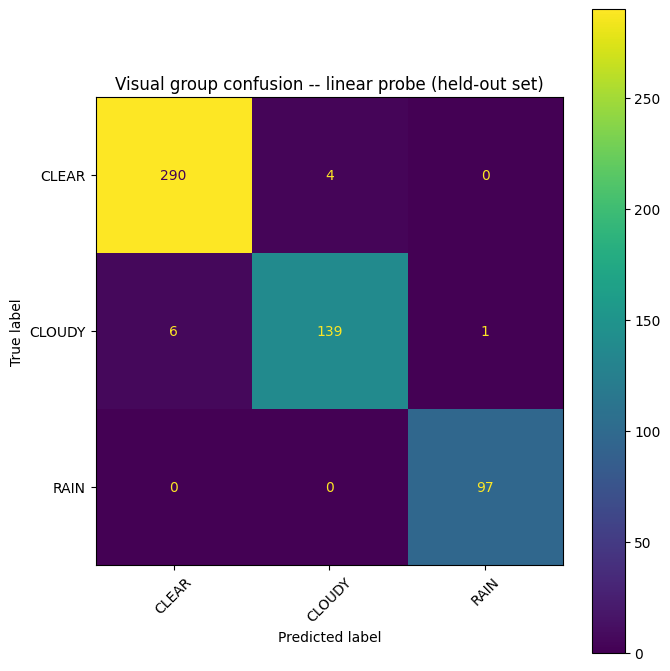

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from app.prompts import GROUP_ORDER

present = [g for g in GROUP_ORDER if g in set(labels)]
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(labels, probed, labels=present, ax=ax, xticks_rotation=45)
ax.set_title("Visual group confusion -- linear probe (held-out set)")
plt.tight_layout()
plt.savefig("training/confusion_matrix.png", dpi=120)
plt.show()

## Outdoor-head threshold curve (informational)

The outdoor head stays zero-shot -- this cell does not feed back into `OUTDOOR_THRESHOLD`, which is a product decision fixed at 0.60 in `tests/test_accuracy.py`. It is reproduced here only because it is a useful diagnostic plot to keep alongside the probe numbers.

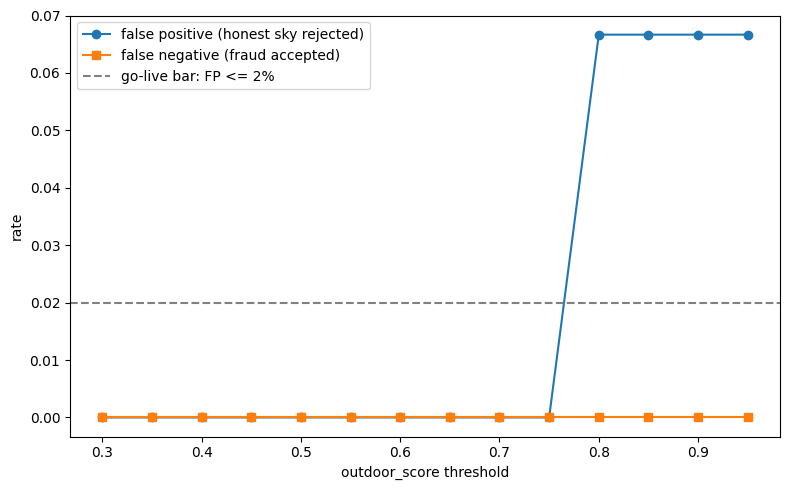

0.30  FP 0.0%  FN 0.0%
0.35  FP 0.0%  FN 0.0%
0.40  FP 0.0%  FN 0.0%
0.45  FP 0.0%  FN 0.0%
0.50  FP 0.0%  FN 0.0%
0.55  FP 0.0%  FN 0.0%
0.60  FP 0.0%  FN 0.0%
0.65  FP 0.0%  FN 0.0%
0.70  FP 0.0%  FN 0.0%
0.75  FP 0.0%  FN 0.0%
0.80  FP 6.7%  FN 0.0%
0.85  FP 6.7%  FN 0.0%
0.90  FP 6.7%  FN 0.0%
0.95  FP 6.7%  FN 0.0%


In [6]:
import csv

golden = Path("data/golden")
rows = list(csv.DictReader((golden / "manifest.csv").open()))
scored = [(model.analyze((golden / "images" / r["filename"]).read_bytes())[0], r["label"])
          for r in rows]

thresholds = [i / 100 for i in range(30, 96, 5)]
fp_rates, fn_rates = [], []
for t in thresholds:
    skies = [s for s, l in scored if l == "sky"]
    frauds = [s for s, l in scored if l == "fraud"]
    fp_rates.append(sum(1 for s in skies if s < t) / len(skies))
    fn_rates.append(sum(1 for s in frauds if s >= t) / len(frauds))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, fp_rates, marker="o", label="false positive (honest sky rejected)")
ax.plot(thresholds, fn_rates, marker="s", label="false negative (fraud accepted)")
ax.axhline(0.02, linestyle="--", color="grey", label="go-live bar: FP <= 2%")
ax.set_xlabel("outdoor_score threshold")
ax.set_ylabel("rate")
ax.legend()
plt.tight_layout()
plt.savefig("training/threshold_curve.png", dpi=120)
plt.show()

for t, fp, fn in zip(thresholds, fp_rates, fn_rates):
    print(f"{t:.2f}  FP {fp:.1%}  FN {fn:.1%}")

## Conclusion

See the printed accuracy numbers above (zero-shot vs probe) and the confusion matrix figure. `OUTDOOR_THRESHOLD` in `tests/test_accuracy.py` is a product decision (0.60) and is not changed by this notebook -- the threshold curve above is informational only, reproduced from the existing golden set for reference alongside the probe numbers.